# 02. Baseline Models
Обучение простых моделей «из коробки»

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import sys
import warnings

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

# Импорт функций
sys.path.append('../src')
from modeling import get_preprocessor, evaluate_model

### 1. Загрузка подготовленных данных

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()

# Инициализируем препроцессор
preprocessor = get_preprocessor(X_train)

# Создадим список для сбора результатов
baseline_results =[]

### 2. Построение Baseline-моделей
Используем pipeline, чтобы препроцессинг применялся автоматически и без утечек

In [3]:
# Модель №1: Логистическая регрессия
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])
f1_logreg = evaluate_model(logreg_pipeline, X_train, y_train, X_val, y_val)
baseline_results.append({'Model': 'Logistic Regression', 'F1_macro': f1_logreg})


# Модель №2: K-Nearest Neighbors (KNN)
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])
f1_knn = evaluate_model(knn_pipeline, X_train, y_train, X_val, y_val)
baseline_results.append({'Model': 'KNN', 'F1_macro': f1_knn})

### 3. Снижение размерности: Logistic Regression + PCA
Посмотрим, как поведет себя линейная модель, если проведем сжатие признакового пространства, оставив, например, 15 главных компонент.

In [4]:
# Модель №3: LogReg + PCA
pca_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=15, random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
f1_pca = evaluate_model(pca_pipeline, X_train, y_train, X_val, y_val)
baseline_results.append({'Model': 'Logistic Regression + PCA(15)', 'F1_macro': f1_pca})

### 4. Ансамблевые модели: RandomForest и LightGBM
Рассмотрим деревья решений и бустинг "из коробки".

In [5]:
# Модель 4: Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
f1_rf = evaluate_model(rf_pipeline, X_train, y_train, X_val, y_val)
baseline_results.append({'Model': 'Random Forest', 'F1_macro': f1_rf})

In [6]:
# Модель №5: LightGBM (Градиентный бустинг)
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
f1_lgbm = evaluate_model(lgbm_pipeline, X_train, y_train, X_val, y_val)
baseline_results.append({'Model': 'LightGBM', 'F1_macro': f1_lgbm})

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3122
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 70
[LightGBM] [Info] Start training from score -0.613307
[LightGBM] [Info] Start training from score -1.094265
[LightGBM] [Info] Start training from score -2.488915
[LightGBM] [Info] Start training from score -3.202581


### 5. Итоги Baseline моделей

In [7]:
baseline_df = pd.DataFrame(baseline_results).sort_values(by='F1_macro', ascending=False).reset_index(drop=True)

print("=-= Результаты базовых моделей (без настройки) =-=")
display(baseline_df)

=-= Результаты базовых моделей (без настройки) =-=


,Model,F1_macro
0,LightGBM,0.848274
1,Random Forest,0.770994
2,Logistic Regression,0.719897
3,Logistic Regression + PCA(15),0.556214
4,KNN,0.484353


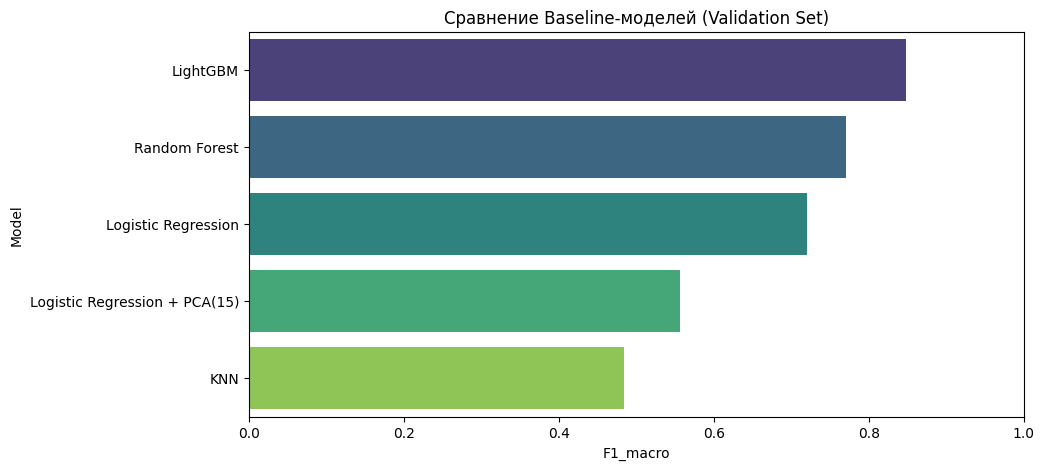

In [8]:
# Отрисовка
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=baseline_df, x='F1_macro', y='Model', palette='viridis')
plt.title('Сравнение Baseline-моделей (Validation Set)')
plt.xlim(0, 1.0)
plt.show()

**Вывод по Baseline:**  
Получили ожидаемый результат с высокой метрикой у градиентного бустинга и RandomForest, в топ-3 также попала логистическая регрессия. В дальнейшем сравним эти результаты с результатами после экспериментов.